In [315]:
import numpy as np 
import polars as pl 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [316]:
df = pl.scan_csv(r'C:\Users\erics\courses\gradml1\crypto_pred_market\data_gather\final_data\final_data.csv').collect()
df = df.filter(pl.col('time_to_close').is_between(100,200))

In [317]:
def _to_datetime(table: pl.DataFrame, cols: list) -> pl.DataFrame:
        for col in cols: 
            table = table.with_columns(
                pl.col(col)
                .str.to_datetime(format="%Y-%m-%dT%H:%M:%S%.f%#z", strict=False)
                .alias(col)
            )
        return table

df = _to_datetime(df, cols = ['curr_time', 'open_time', 'close_time', 'prev_time'])


In [318]:
event_col_ids = ['open_time', 'close_time']
event_ids = (df.select(event_col_ids).unique().sort('open_time'))
n = 0.7

X_train_ids = event_ids[:round(n*len(event_ids))]
X_test_ids = event_ids[round(n*len(event_ids)):]

y_train = df.join(X_train_ids, on=event_col_ids, how = 'inner').select('outcome')
X_train = df.join(X_train_ids, on=event_col_ids, how = 'inner').drop('curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 'next_price_dollars_lead1', 'yes_ask_dollars', 'no_ask_dollars', 'yes_mid_dollars', 'yes_bid_dollars', 'no_bid_dollars', 'last_price_dollars')

y_test = df.join(X_test_ids, on=event_col_ids, how = 'inner').select('outcome')
X_test = df.join(X_test_ids, on=event_col_ids, how = 'inner').drop('curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 'next_price_dollars_lead1', 'yes_ask_dollars', 'no_ask_dollars', 'yes_mid_dollars', 'yes_bid_dollars', 'no_bid_dollars', 'last_price_dollars')

log_reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log_reg.fit(X_train.to_numpy(), y_train.to_numpy().ravel())


log_reg.score(X_test.to_numpy(), y_test.to_numpy().ravel())
y_pred = log_reg.predict(X_test.to_numpy())
print("Accuracy:", accuracy_score(y_test.to_numpy().ravel(), y_pred))
print(confusion_matrix(y_test.to_numpy().ravel(), y_pred))
print(classification_report(y_test.to_numpy().ravel(), y_pred))

        

Accuracy: 0.893305024769993
[[16054  1936]
 [ 1833 15502]]
              precision    recall  f1-score   support

           0       0.90      0.89      0.89     17990
           1       0.89      0.89      0.89     17335

    accuracy                           0.89     35325
   macro avg       0.89      0.89      0.89     35325
weighted avg       0.89      0.89      0.89     35325



In [319]:
len(X_train.columns)

58

In [320]:
from sklearn.model_selection import GroupShuffleSplit

groups = df['open_time'].cast(str) + '_' + df['close_time'].cast(str)

gss = GroupShuffleSplit(n_splits=10, test_size=0.3)
train_idx, test_idx = next(gss.split(df, groups=groups.to_numpy()))

drop_cols = ['curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 
             'next_price_dollars_lead1', 'yes_ask_dollars', 'no_ask_dollars', 
             'yes_mid_dollars', 'yes_bid_dollars', 'no_bid_dollars', 'last_price_dollars']


X_train = df[train_idx].drop(drop_cols)
y_train = df[train_idx].select('outcome')
X_test = df[test_idx].drop(drop_cols)
y_test = df[test_idx].select('outcome')


log_reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, penalty='l2', C=0.016, ))
log_reg.fit(X_train.to_numpy(), y_train.to_numpy().ravel())


log_reg.score(X_test.to_numpy(), y_test.to_numpy().ravel())
y_pred = log_reg.predict(X_test.to_numpy())
print("Accuracy:", accuracy_score(y_test.to_numpy().ravel(), y_pred))
print(confusion_matrix(y_test.to_numpy().ravel(), y_pred))
print(classification_report(y_test.to_numpy().ravel(), y_pred))


c:\Users\erics\courses\gradml1\crypto_pred_market\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy: 0.8958912661029453
[[16602  2391]
 [ 1278 14971]]
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     18993
           1       0.86      0.92      0.89     16249

    accuracy                           0.90     35242
   macro avg       0.90      0.90      0.90     35242
weighted avg       0.90      0.90      0.90     35242



In [321]:
# # ===============================================================
# # TSFRESH feature extraction — LEAKY test (full-event aggregation)
# # Purpose: check if time-series features add predictive power
# # ===============================================================

# from tsfresh import extract_features, select_features
# from tsfresh.feature_extraction import MinimalFCParameters
# from tsfresh.utilities.dataframe_functions import impute
# import pandas as pd
# import numpy as np
# from sklearn.linear_model import LogisticRegression
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import brier_score_loss, log_loss

# # ---------------------------------------------------------------
# # 1. Prep: long-format time series keyed by event
# # ---------------------------------------------------------------
# df_pd = df.to_pandas()
# df_pd['event_id'] = df_pd['open_time'].astype(str) + '_' + df_pd['close_time'].astype(str)

# # Pick 2-3 key time-series columns to extract from. More = more memory.
# TS_COLS = ['btc_spot_price', 'distance_from_strike', 'yes_mid_dollars']

# # Run tsfresh once per column (long format is cleaner)
# all_extracted = []
# for col in TS_COLS:
#     print(f"Extracting tsfresh features for {col}...")
#     ts_frame = df_pd[['event_id', 'curr_time', col]].copy()
#     extracted = extract_features(
#         ts_frame,
#         column_id='event_id',
#         column_sort='curr_time',
#         column_value=col,
#         default_fc_parameters=MinimalFCParameters(),
#         n_jobs=4,
#         disable_progressbar=True,
#     )
#     # Prefix columns so they don't collide
#     extracted.columns = [f"ts_{col}__{c}" for c in extracted.columns]
#     all_extracted.append(extracted)

# tsfresh_features = pd.concat(all_extracted, axis=1)
# impute(tsfresh_features)  # handles NaNs/infs in place
# print(f"Raw tsfresh features: {tsfresh_features.shape[1]}")

# # ---------------------------------------------------------------
# # 2. Select features using FDR filter on train events only
# # ---------------------------------------------------------------
# # Get one outcome per event (they're identical within an event)
# y_per_event = df_pd.groupby('event_id')['outcome'].first()

# # Map train_idx / test_idx to event_ids (avoid test leakage in selection)
# train_event_ids = set(df_pd.iloc[train_idx]['event_id'].unique())
# test_event_ids  = set(df_pd.iloc[test_idx]['event_id'].unique())

# train_mask = tsfresh_features.index.isin(train_event_ids)
# X_ts_train_event = tsfresh_features[train_mask]
# y_ts_train_event = y_per_event.loc[X_ts_train_event.index]

# selected = select_features(X_ts_train_event, y_ts_train_event, fdr_level=0.01)
# print(f"After FDR selection (fdr=0.01): {selected.shape[1]} features kept")

# # Extract those same selected columns from the full feature set (so test rows have them too)
# tsfresh_selected = tsfresh_features[selected.columns]

# # ---------------------------------------------------------------
# # 3. Merge tsfresh features back to tick level
# # ---------------------------------------------------------------
# df_pd = df_pd.merge(
#     tsfresh_selected,
#     left_on='event_id',
#     right_index=True,
#     how='left',
# )

# # ---------------------------------------------------------------
# # 4. Rebuild X_train / X_test with expanded features
# # ---------------------------------------------------------------
# drop_cols = [
#     'curr_time', 'outcome', 'open_time', 'close_time', 'prev_time',
#     'next_price_dollars_lead1', 'yes_ask_dollars', 'no_ask_dollars',
#     'yes_mid_dollars', 'yes_bid_dollars', 'no_bid_dollars', 'last_price_dollars',
#     'event_id',
# ]

# X_train_ts = df_pd.iloc[train_idx].drop(columns=drop_cols)
# y_train_ts = df_pd.iloc[train_idx]['outcome']
# X_test_ts  = df_pd.iloc[test_idx].drop(columns=drop_cols)
# y_test_ts  = df_pd.iloc[test_idx]['outcome']

# print(f"X_train expanded: {X_train_ts.shape}")

# # ---------------------------------------------------------------
# # 5. Refit log_reg and compare
# # ---------------------------------------------------------------
# log_reg_ts = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
# log_reg_ts.fit(X_train_ts.to_numpy(), y_train_ts.to_numpy())

# p_hat_ts = log_reg_ts.predict_proba(X_test_ts.to_numpy())[:, 1]
# y_true = y_test_ts.to_numpy()

# print("\n=== BASELINE (no tsfresh) ===")
# print(f"  Hard-case acc: 0.6276  (your previous number)")

# print("\n=== WITH tsfresh features (LEAKY) ===")
# print(f"  Overall accuracy: {((p_hat_ts > 0.5).astype(int) == y_true).mean():.4f}")
# print(f"  Brier score:      {brier_score_loss(y_true, p_hat_ts):.4f}")
# print(f"  Log loss:         {log_loss(y_true, p_hat_ts):.4f}")

# mid_mask = ((p_hat_ts > 0.35) & (p_hat_ts < 0.45)) | ((p_hat_ts > 0.55) & (p_hat_ts < 0.65))
# if mid_mask.sum() > 0:
#     hard_acc = ((p_hat_ts[mid_mask] > 0.5).astype(int) == y_true[mid_mask]).mean()
#     print(f"  Hard-case acc:    {hard_acc:.4f}  (n={mid_mask.sum()})")

# full_mid = (p_hat_ts > 0.35) & (p_hat_ts < 0.65)
# if full_mid.sum() > 0:
#     full_hard = ((p_hat_ts[full_mid] > 0.5).astype(int) == y_true[full_mid]).mean()
#     print(f"  Hard-case acc (full 0.35-0.65): {full_hard:.4f}  (n={full_mid.sum()})")

# print("\n⚠️  Remember: these features leak future info within each event.")
# print("    Use this only to check if time-series features have signal.")


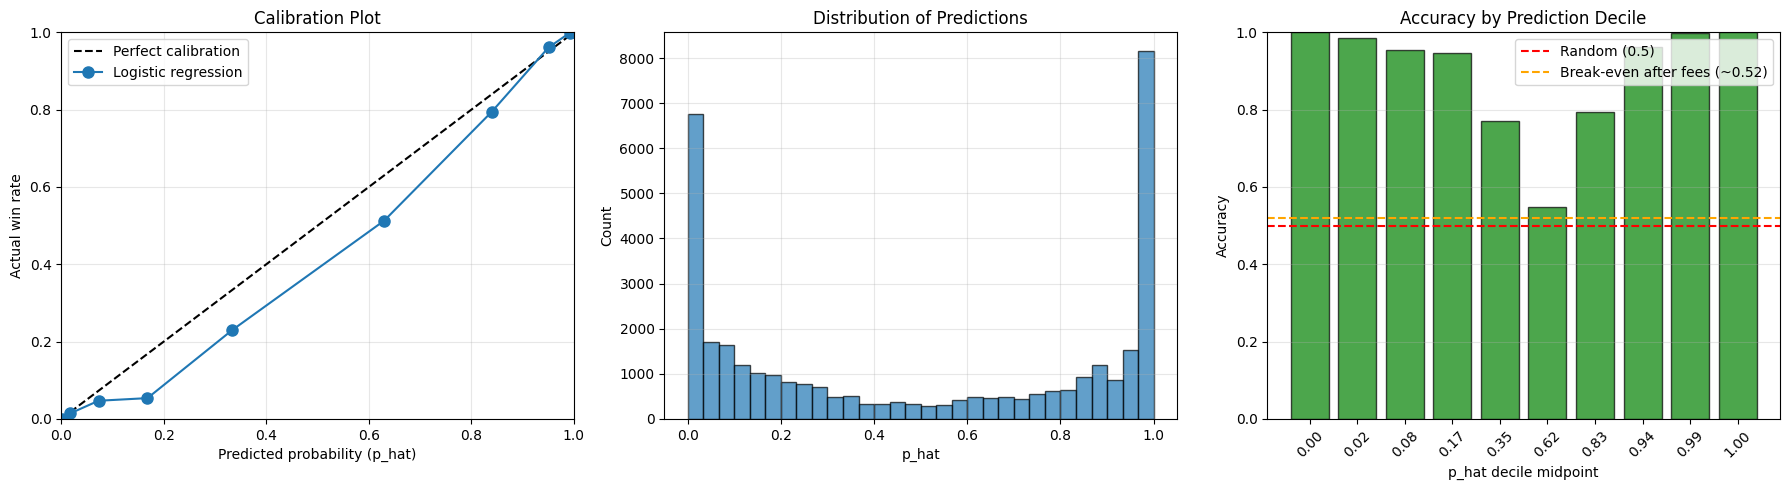

Overall accuracy: 0.8959
Brier score:      0.0761  (0.25 = random, lower = better)
Log loss:         0.2473  (0.693 = random, lower = better)

Hard-case accuracy (0.35 < p_hat < 0.65): 0.5634  (n=939)
  >0.55 = real edge. 0.50-0.52 = random after fees.


In [322]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
import matplotlib.pyplot as plt
import numpy as np

# Predicted probabilities for positive class
p_hat = log_reg.predict_proba(X_test.to_numpy())[:, 1]
y_true = y_test.to_numpy().ravel()

# Calibration curve
prob_true, prob_pred = calibration_curve(y_true, p_hat, n_bins=10, strategy='quantile')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Reliability diagram
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0].plot(prob_pred, prob_true, 'o-', label='Logistic regression', markersize=8)
axes[0].set_xlabel('Predicted probability (p_hat)')
axes[0].set_ylabel('Actual win rate')
axes[0].set_title('Calibration Plot')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# 2. Distribution of p_hat
axes[1].hist(p_hat, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('p_hat')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Predictions')
axes[1].grid(alpha=0.3)

# 3. Accuracy per decile — shows where edge lives
decile_edges = np.quantile(p_hat, np.linspace(0, 1, 11))
decile_acc = []
decile_mid = []
for i in range(10):
    mask = (p_hat >= decile_edges[i]) & (p_hat <= decile_edges[i+1])
    if mask.sum() > 0:
        preds = (p_hat[mask] > 0.5).astype(int)
        decile_acc.append((preds == y_true[mask]).mean())
        decile_mid.append((decile_edges[i] + decile_edges[i+1]) / 2)

axes[2].bar(range(len(decile_acc)), decile_acc, color='green', alpha=0.7, edgecolor='black')
axes[2].axhline(0.5, color='red', linestyle='--', label='Random (0.5)')
axes[2].axhline(0.52, color='orange', linestyle='--', label='Break-even after fees (~0.52)')
axes[2].set_xticks(range(len(decile_acc)))
axes[2].set_xticklabels([f'{m:.2f}' for m in decile_mid], rotation=45)
axes[2].set_xlabel('p_hat decile midpoint')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Accuracy by Prediction Decile')
axes[2].legend()
axes[2].grid(alpha=0.3, axis='y')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"Overall accuracy: {((p_hat > 0.5).astype(int) == y_true).mean():.4f}")
print(f"Brier score:      {brier_score_loss(y_true, p_hat):.4f}  (0.25 = random, lower = better)")
print(f"Log loss:         {log_loss(y_true, p_hat):.4f}  (0.693 = random, lower = better)")

# THE critical number — hard-case accuracy
mid_mask = (p_hat > 0.45) & (p_hat < 0.55) 
if mid_mask.sum() > 0:
    hard_acc = ((p_hat[mid_mask] > 0.5).astype(int) == y_true[mid_mask]).mean()
    print(f"\nHard-case accuracy (0.35 < p_hat < 0.65): {hard_acc:.4f}  (n={mid_mask.sum()})")
    print("  >0.55 = real edge. 0.50-0.52 = random after fees.")



In [323]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import TimeSeriesSplit  # or KFold for iid data

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegressionCV(
        Cs=np.logspace(-4, 4, 30),
        cv=TimeSeriesSplit(n_splits=5),
        penalty="l2",
        scoring="neg_log_loss",
        max_iter=2000,
        refit=True,
    )),
])
pipe.fit(X_train, y_train)

best_C = pipe.named_steps["clf"].C_[0]
print(f"Best C: {best_C:.4f}  (λ ≈ {1/best_C:.4f})")

c:\Users\erics\courses\gradml1\crypto_pred_market\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\erics\courses\gradml1\crypto_pred_market\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\erics\courses\gradml1\crypto_pred_market\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

KeyboardInterrupt: 

In [ ]:
import pandas as pd

feature_names = X_train.columns  # polars
coefs = log_reg.named_steps['logisticregression'].coef_[0]

importance_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

print(importance_df.head(20))


                       feature      coef  abs_coef
2         distance_from_strike  7.411542  7.411542
37    SOL_distance_from_strike -0.808315  0.808315
11    ETH_distance_from_strike -0.377322  0.377322
54     btc_spot_return_vol_30s  0.246172  0.246172
24    XRP_distance_from_strike -0.186340  0.186340
57      btc_spot_size_mean_30s -0.175433  0.175433
55      btc_spot_return_vol_5m -0.156879  0.156879
34      SOL_last_price_dollars -0.118439  0.118439
41  SOL_yes_mid_change_std_60s  0.114525  0.114525
8       ETH_last_price_dollars  0.105239  0.105239
47              btc_spot_price  0.081654  0.081654
6       yes_mid_change_std_60s -0.080035  0.080035
52         btc_spot_return_15s  0.074856  0.074856
43         SOL_yes_ask_dollars  0.071548  0.071548
46          SOL_no_bid_dollars -0.071548  0.071548
35         SOL_yes_mid_dollars  0.070542  0.070542
27  XRP_yes_mid_change_std_30s -0.070304  0.070304
45          SOL_no_ask_dollars -0.069352  0.069352
44         SOL_yes_bid_dollars 

ModuleNotFoundError: No module named 'tsfresh'

In [ ]:

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # add project root to path

from trading.save_log_reg import save_log_reg_artifacts
save_log_reg_artifacts(log_reg, list(X_train.columns))
from trading.save_log_reg import save_log_reg_artifacts

# Get the exact column order from X_train (must match FEATURE_NAMES in model.py)
feature_names = list(X_train.columns)  # polars: X_train.columns returns a list
save_log_reg_artifacts(log_reg, feature_names)


Saved log_reg artifacts to C:\Users\erics\courses\gradml1\crypto_pred_market\trading\model_artifacts.npz
  draws:  (1, 59)  (1 draw = deterministic prediction, p_std=0)
  means:  (58,)
  stds:   (58,)
  intercept: -0.0390
  |coef| max=7.4115  mean=0.1978
Saved log_reg artifacts to C:\Users\erics\courses\gradml1\crypto_pred_market\trading\model_artifacts.npz
  draws:  (1, 59)  (1 draw = deterministic prediction, p_std=0)
  means:  (58,)
  stds:   (58,)
  intercept: -0.0390
  |coef| max=7.4115  mean=0.1978


c:\Users\erics\courses\gradml1\crypto_pred_market\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Overall accuracy: 0.8733
Brier score:      0.0925
Log loss:         0.3150
ROC AUC:          0.9537
Hard-case accuracy (0.35 < p_hat < 0.65): 0.5116  (n=6449)


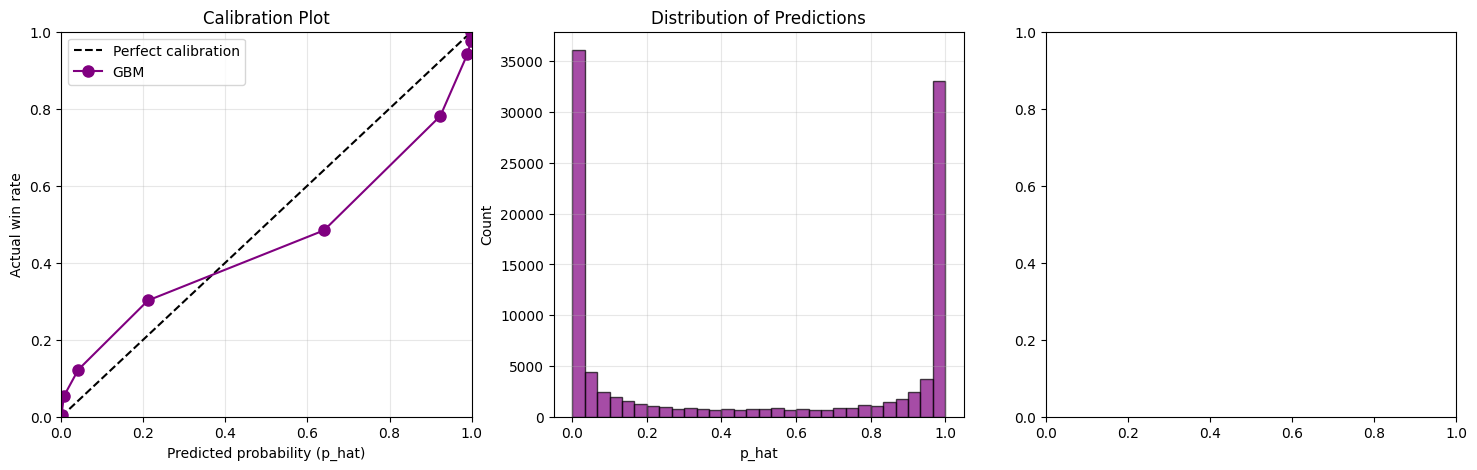

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

from lightgbm import LGBMClassifier
gbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                     min_child_samples=50, reg_lambda=1.0, random_state=42, verbose=-1)


gbm.fit(X_train.to_numpy(), y_train.to_numpy().ravel())

# ---- Predict ---- #
p_hat = gbm.predict_proba(X_test.to_numpy())[:, 1]
y_true = y_test.to_numpy().ravel()

# ---- Metrics ---- #
print(f"Overall accuracy: {((p_hat > 0.5).astype(int) == y_true).mean():.4f}")
print(f"Brier score:      {brier_score_loss(y_true, p_hat):.4f}")
print(f"Log loss:         {log_loss(y_true, p_hat):.4f}")
print(f"ROC AUC:          {roc_auc_score(y_true, p_hat):.4f}")

mid_mask = (p_hat > 0.35) & (p_hat < 0.65)
if mid_mask.sum() > 0:
    hard_acc = ((p_hat[mid_mask] > 0.5).astype(int) == y_true[mid_mask]).mean()
    print(f"Hard-case accuracy (0.35 < p_hat < 0.65): {hard_acc:.4f}  (n={mid_mask.sum()})")

# ---- Plots ---- #
prob_true, prob_pred = calibration_curve(y_true, p_hat, n_bins=10, strategy='quantile')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0].plot(prob_pred, prob_true, 'o-', label='GBM', markersize=8, color='purple')
axes[0].set_xlabel('Predicted probability (p_hat)')
axes[0].set_ylabel('Actual win rate')
axes[0].set_title('Calibration Plot')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

axes[1].hist(p_hat, bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1].set_xlabel('p_hat'); axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Predictions'); axes[1].grid(alpha=0.3)

decile_edges = np.quantile(p_hat, np.linspace(0, 1, 11))
decile_acc, decile_mid = [], []
for i in range(10):
    mask = (p_hat >= decile_edges[i]) & (p_hat <= decile_edges[i+1])
    if mask.sum() > 0:
        decile_acc.append(((p_hat[mask] > 0.5).astype(int) == y_true[mask]).mean())
        decile_mid.append((decile_edges[i] + decile_edges[i+1]) / 2)


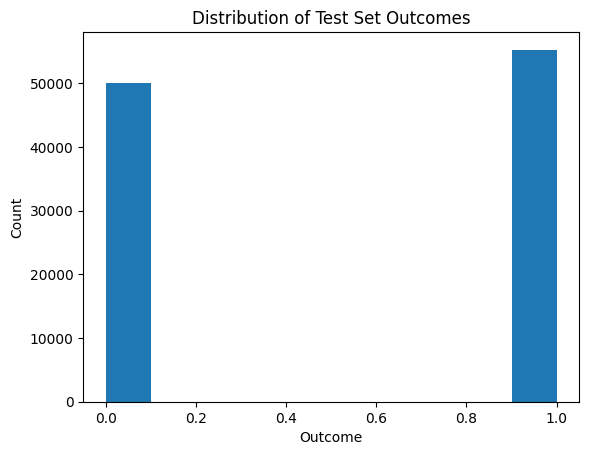

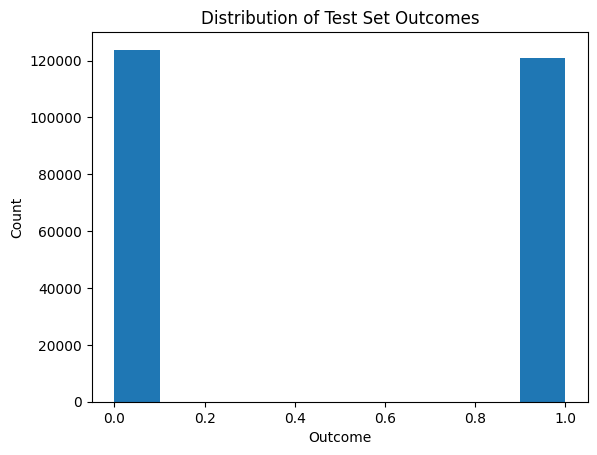

In [ ]:
import matplotlib.pyplot as plt 
plt.figure()
plt.hist(y_test)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Test Set Outcomes')
plt.show()


import matplotlib.pyplot as plt 
plt.figure()
plt.hist(y_train)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Test Set Outcomes')
plt.show()

In [ ]:
# probability of class 1 p_hat := [class0_prob, class1_prob]
p_hat = log_reg.predict_proba(X_test.to_numpy())[:,-1]
q = df[test_idx].select('yes_mid_dollars').to_numpy().ravel()

p_hat - q

ev_yes = p_hat - q 
ev_no = q-p_hat

threshold = 0.1 
ev_yes

array([0.13033494, 0.13141302, 0.13103144, ..., 0.09096198, 0.09141145,
       0.09190816], shape=(105238,))

In [ ]:
# import numpy as np
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import GroupShuffleSplit

# groups = df["open_time"].cast(str) + "_" + df["close_time"].cast(str)

# gss = GroupShuffleSplit(n_splits=5, test_size=0.3)
# train_idx, test_idx = next(gss.split(df, groups=groups.to_numpy()))

# drop_cols = [
#     "curr_time",
#     "outcome",
#     "open_time",
#     "close_time",
#     "prev_time",
#     "next_price_dollars_lead1",
#     'yes_mid_dollars',
#     'yes_ask_dollars',
#     'no_ask_dollars'
# ]
# q_mid = df[test_idx]["yes_mid_dollars"].to_numpy().ravel()
# yes_ask = df[test_idx]["yes_ask_dollars"].to_numpy().ravel()
# no_ask = df[test_idx]["no_ask_dollars"].to_numpy().ravel()

# X_train = df[train_idx].drop(drop_cols)
# y_train = df[train_idx].select("outcome")
# X_test = df[test_idx].drop(drop_cols)
# y_test = df[test_idx].select("outcome")

# X_train_np = X_train.to_numpy()
# y_train_np = y_train.to_numpy().ravel()
# X_test_np = X_test.to_numpy()
# y_test_np = y_test.to_numpy().ravel()

# model = make_pipeline(
#     StandardScaler(),
#     LogisticRegression(max_iter=10000)
# )

# model.fit(X_train_np, y_train_np)

# p_hat = model.predict_proba(X_test_np)[:, 1]


# # Signal generation uses midpoint
# signal_yes = p_hat - q_mid
# signal_no = q_mid - p_hat

# # threshold = 0.1

# threshold_lst = []
# pnl_lst = []
# num_trades_lst = []
# wr_list =[]

# for t in range(99): 
#     threshold = t/100

#     position = np.zeros(len(p_hat))
#     position[signal_yes > threshold] = 1
#     position[signal_no > threshold] = -1

#     # Executable EV uses actual ask prices
#     ev_yes_exec = p_hat - yes_ask
#     ev_no_exec = (1 - p_hat) - no_ask

#     pnl = np.zeros(len(p_hat))

#     yes_mask = position == 1
#     pnl[yes_mask] = np.where(
#         y_test_np[yes_mask] == 1,
#         1 - yes_ask[yes_mask]-0.02,
#         -yes_ask[yes_mask]-0.02
#     )

#     no_mask = position == -1
#     pnl[no_mask] = np.where(
#         y_test_np[no_mask] == 0,
#         1 - no_ask[no_mask]-0.02,
#         -no_ask[no_mask]-0.02
#     )

#     # trade_ev = np.where(
#     #     position == 1,
#     #     ev_yes_exec,
#     #     np.where(position == -1, ev_no_exec, np.nan)
#     # )

#     trade_mask = position != 0
#     threshold_lst.append(threshold)
#     if trade_mask.sum() > 0:
#         pnl_lst.append(pnl[trade_mask].sum())
#     else:
#         pnl_lst.append(np.nan)

#     num_trades_lst.append(trade_mask.sum())
#     wr_list.append((pnl[trade_mask] > 0).mean() if trade_mask.sum() > 0 else np.nan)

# # print("Number of trades:", trade_mask.sum())
# # print("Average signal of trades:", np.nanmean(np.where(position == 1, signal_yes, np.where(position == -1, signal_no, np.nan))))
# # print("Average executable EV of trades:", np.nanmean(trade_ev))
# # print("Average PnL per trade:", pnl[trade_mask].mean())
# # print("Total PnL:", pnl[trade_mask].sum())
# # print("Win rate:", (pnl[trade_mask] > 0).mean())
# # print("Worst trade:", pnl[trade_mask].min())
# # print("5th percentile PnL:", np.quantile(pnl[trade_mask], 0.05))



In [ ]:
# plt.plot(threshold_lst, pnl_lst)
# plt.axvline(x=0.05, color='red', linestyle='--', label='Threshold = 0.05')
# plt.xlabel('Threshold')
# plt.ylabel('Total PnL')
# plt.title('Total PnL vs Threshold')
# # plt.plot(threshold_lst, np.log(num_trades_lst))

In [ ]:
# from sklearn.metrics import (
#     accuracy_score,
#     log_loss,
#     brier_score_loss,
#     roc_auc_score,
#     roc_curve,
#     confusion_matrix,
#     classification_report,
# )
# import matplotlib.pyplot as plt

# y_true = y_test.to_numpy().ravel()
# y_pred = log_reg.predict(X_test.to_numpy())
# y_prob = log_reg.predict_proba(X_test.to_numpy())[:, 1]

# print("Accuracy:", accuracy_score(y_true, y_pred))
# print("Log Loss:", log_loss(y_true, y_prob))
# print("Brier Score:", brier_score_loss(y_true, y_prob))
# print("ROC AUC:", roc_auc_score(y_true, y_prob))
# print()
# print("Confusion Matrix:")
# print(confusion_matrix(y_true, y_pred))
# print()
# print("Classification Report:")
# print(classification_report(y_true, y_pred))


In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"LogReg AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


ValueError: Found input variables with inconsistent numbers of samples: [105238, 105410]